In [1]:
from vmc_ising2 import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    get_eval_set,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd
from itertools import chain
import lattice_symmetries as ls

import scipy
import scipy.sparse
import scipy.sparse.linalg

from kagome_round import get_kagome36
from misc_utils import smooth

from datetime import datetime

time_format = "%Y_%m_%d_%H_%M_%S"

Running dilated_nns_xors.py


In [30]:
# load_tasks = ["80", "84", "85", "86", "87"]
# load_tasks = ["80", "88", "89", "92", "93", "94", "95", "96", "97", "98", "100", "101"]
# load_tasks = ["0", "1", "5", "4", "6", "7", "8"]
load_tasks = ["0", "9"]
df = (
    read_jsonl_to_df(
        chain(*[list(output_dir.glob(f"{task}/results.jsonl")) for task in load_tasks])
        #   + list(output_dir.glob("58/results.jsonl"))
    )
    .fillna(keep_serializable(default_config))
    .fillna({"run": 0})
    .assign(
        current_timestamp=lambda df: df["current_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
        start_timestamp=lambda df: df["start_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
    )
    # .assign(
    #     n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
    #         "cumsum"
    #     )
    # )
)

/tmp/nix-shell.0cm8Ru/ipykernel_797201/3208391498.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(keep_serializable(default_config))


/vol/tcm10/ischurov/frustrations-eda/misc_utils.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(groupby)


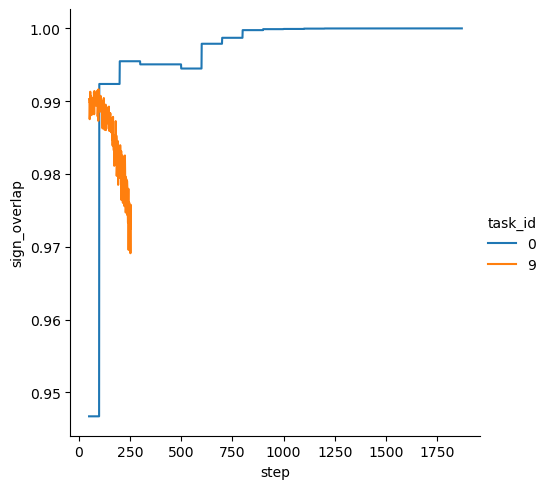

In [33]:
sns.relplot(
    df.astype({"task_id": "category"}).query("task_id in [0, 9] and not warm_up")
     .pipe(smooth("amplitude_overlap", 100, ["task_id"])).astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    # .pipe(smooth("amplitude_overlap_diff", 1000, ["task_id"]))
    # .pipe(smooth("sign_overlap", 100, ["task_id"]))
    # .pipe(smooth("energy_delta", 100, ["task_id"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="sign_overlap",
    # hue="warm_up",
    kind="line",
    hue="task_id",
    # col_wrap=3,
)
# plt.ylim(0, 5)
# plt.ylim(0.9, 1)

In [25]:
# config = get_config(7)
# system = get_system(config)
# (lambda x: x[1] - x[0])(system.get_eigenstates(2)[0])

In [4]:
# system.get_eigenstates(2)[0]

In [5]:
df.query("not warm_up").groupby("task_id").apply(
    lambda df_group: df_group.assign(
        current_timestamp_diff=lambda x: x["current_timestamp"].diff()
    )
).reset_index(drop=True).groupby("task_id")["current_timestamp_diff"].mean()

/tmp/nix-shell.G58hEy/ipykernel_878254/3795369900.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.query('not warm_up').groupby("task_id").apply(


task_id
0   0 days 00:00:00.160500260
1   0 days 00:00:00.150392817
4   0 days 00:00:05.766944661
5   0 days 00:00:03.919281614
6   0 days 00:00:04.220835583
7   0 days 00:00:23.916514057
8   0 days 00:00:04.749744289
Name: current_timestamp_diff, dtype: timedelta64[ns]

In [34]:
(lambda x: x["extension_size"] / x["relative_extension_size"])(
    df.query("task_id == 7 and not warm_up").iloc[0]["extension_size"]
)

IndexError: invalid index to scalar variable.

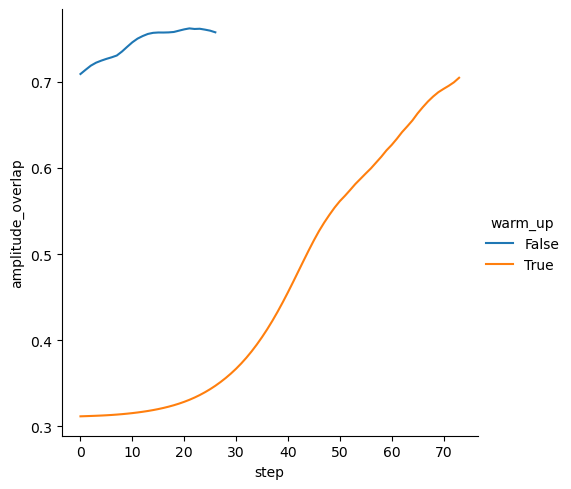

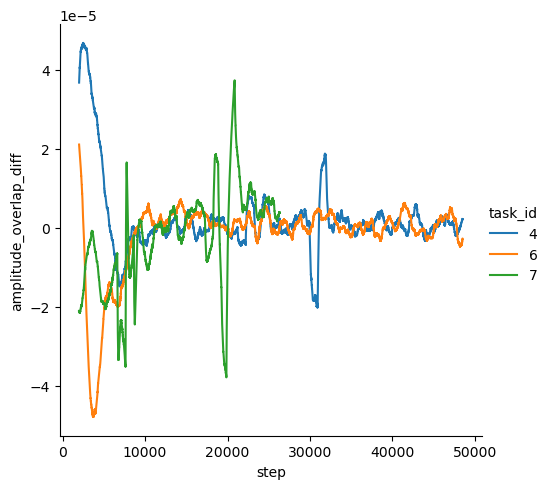

In [7]:
sns.relplot(
    df.query("task_id in [4, 6, 7] and step > 500")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"]))
    .astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    .pipe(smooth("amplitude_overlap_diff", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="amplitude_overlap_diff",
    # hue="warm_up",
    kind="line",
    hue="task_id",
    # col_wrap=3,
)

In [ ]:
df.query("task_id == 6 and warm_up")

,vmc.outer_sample_size,vmc.inner_sample_size,vmc.inner_epochs,vmc.max_steps,vmc.lr,vmc.batch_size,vmc.weight_decay,vmc.eval_set_max_size,vmc.device,system.lattice,...,n_connected_components,largest_connected_component_size,log_prob_fn.split_group_res_conv_net.extend_filter1,log_prob_fn.split_group_res_conv_net.filter_size,log_prob_fn.split_group_res_conv_net.channels,log_prob_fn.split_group_res_conv_net.res_blocks,log_prob_fn.split_group_res_conv_net.additional_generators,log_prob_fn.invariant_res_cnn.resnet_blocks,log_prob_fn.invariant_res_cnn.resnet_block_depth,log_prob_fn.invariant_res_cnn.hidden_channels
103957,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103958,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103959,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103960,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103961,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103962,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103963,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103964,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103965,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103966,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None


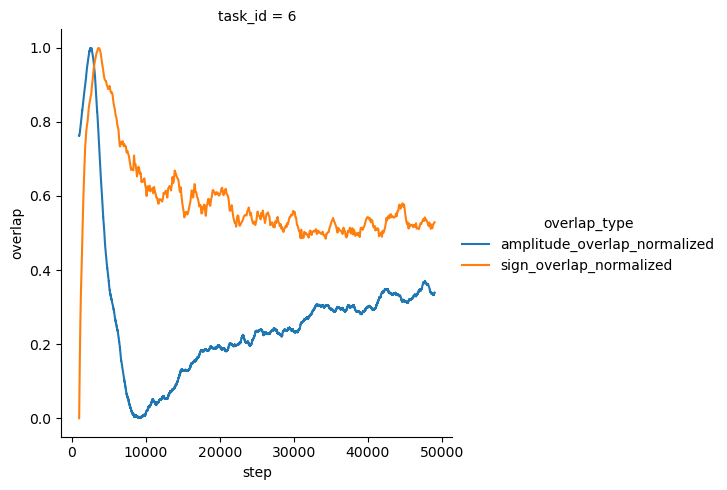

In [ ]:
sns.relplot(
    df.query("task_id == 6")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        amplitude_overlap_normalized=lambda x: (
            x["amplitude_overlap"] - x["amplitude_overlap"].min()
        )
        / (x["amplitude_overlap"].max() - x["amplitude_overlap"].min())
    )
    .assign(
        sign_overlap_normalized=lambda x: (x["sign_overlap"] - x["sign_overlap"].min())
        / (x["sign_overlap"].max() - x["sign_overlap"].min())
    )
    .melt(
        id_vars=["step", "task_id"],
        value_vars=["amplitude_overlap_normalized", "sign_overlap_normalized"],
        var_name="overlap_type",
        value_name="overlap",
    ),
    x="step",
    y="overlap",
    hue="overlap_type",
    kind="line",
    col="task_id",
)

In [ ]:
window = 100
(
    df.query("task_id == 6 and step > 500")
    .pipe(smooth("amplitude_overlap", window, ["task_id"]))
    .pipe(smooth("sign_overlap", window, ["task_id"]))
    .set_index("step")[["amplitude_overlap", "sign_overlap"]]
    .idxmax()
)

amplitude_overlap    2681
sign_overlap         3350
dtype: int64

In [8]:
window = 1000
corrs = []
for lag in range(-300, 300):
    corrs.append(
        {
            "lag": lag,
            "corr": df.query("task_id == 6 and step > 500")
            .pipe(smooth("amplitude_overlap", window, ["task_id"]))
            .pipe(smooth("sign_overlap", window, ["task_id"]))
            .assign(
                sign_overlap_delta=lambda x: x["sign_overlap"].diff(),
                amplitude_overlap_delta=lambda x: x["amplitude_overlap"].diff(),
                amplitude_overlap_delta_shift=lambda x: x[
                    "amplitude_overlap_delta"
                ].shift(lag),
                amplitude_overlap_shift=lambda x: x["amplitude_overlap"].shift(lag),
            )[["sign_overlap", "amplitude_overlap_shift"]]
            .corr()
            .iloc[0, 1],
        }
    )

KeyboardInterrupt: 

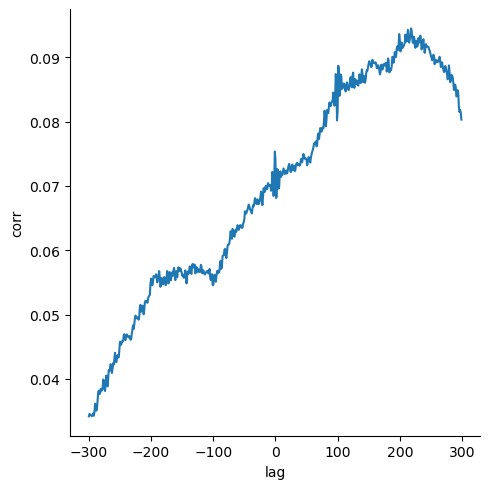

In [ ]:
sns.relplot(pd.DataFrame(corrs), x="lag", y="corr", kind="line")

In [ ]:
pd.DataFrame(dict(x=[1, 2, 3, 4], y=[10, 20, 30, 40])).assign(
    y=lambda x: x["y"].shift(-1)
)

,x,y
0,1,20.0
1,2,30.0
2,3,40.0
3,4,NaN
